# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Ardian
- Email: elytra70@gmail.com
- Id Dicoding: ardian786

## Persiapan

### Menyiapkan library yang dibutuhkan

In [26]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

### Menyiapkan data yang akan diguankan

## Data Understanding

In [27]:
df = pd.read_csv('data.csv', sep=';')

In [28]:
display(df.head())

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [29]:
print("--- Dataset Info ---")
df.info()


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualificati

In [31]:
print("\n--- Missing Values ---")
df.duplicated().sum()


--- Missing Values ---


np.int64(0)

## Data Preparation / Preprocessing

In [32]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target']


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


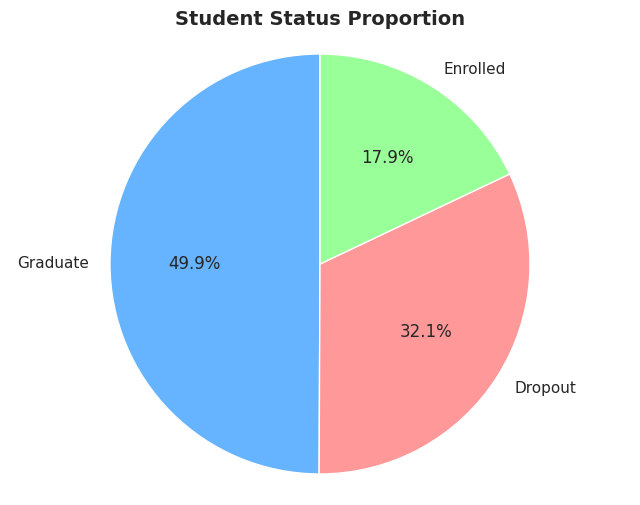

In [35]:
target_counts = df['Target'].value_counts()
print(target_counts)

plt.figure(figsize=(8, 6))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=['#66b3ff', '#ff9999', '#99ff99'])
plt.title('Student Status Proportion', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

Data shape after removing 'Enrolled': 3630 rows

New Binary Target Distribution:
Target
0    2209
1    1421
Name: count, dtype: int64



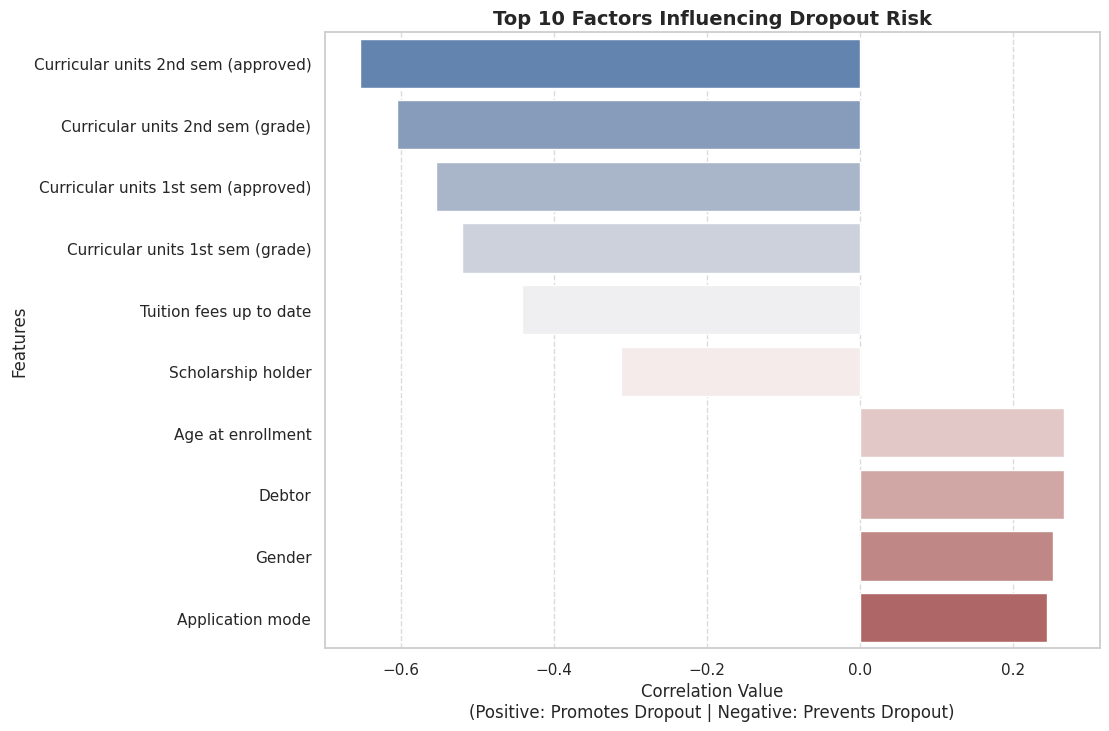


Top 10 Most Important Features:
1. Curricular units 2nd sem (approved)
2. Curricular units 2nd sem (grade)
3. Curricular units 1st sem (approved)
4. Curricular units 1st sem (grade)
5. Tuition fees up to date
6. Scholarship holder
7. Age at enrollment
8. Debtor
9. Gender
10. Application mode


In [43]:
df_clean = df[df['Target'] != 'Enrolled'].copy()
df_clean['Target'] = df_clean['Target'].map({'Dropout': 1, 'Graduate': 0})

print(f"Data shape after removing 'Enrolled': {df_clean.shape[0]} rows")
print(f"\nNew Binary Target Distribution:\n{df_clean['Target'].value_counts()}\n")

correlation = df_clean.corr()
target_corr = correlation['Target'].sort_values(ascending=False)
top_10_features = target_corr.abs().sort_values(ascending=False).index[1:11]

plt.figure(figsize=(10, 8))
sns.barplot(x=target_corr[top_10_features].values, y=top_10_features, palette='vlag')
plt.title('Top 10 Factors Influencing Dropout Risk', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Value\n(Positive: Promotes Dropout | Negative: Prevents Dropout)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\nTop 10 Most Important Features:")
for i, feature in enumerate(top_10_features.tolist(), 1):
    print(f"{i}. {feature}")

## Modeling

In [39]:
X = df_clean.drop(columns=['Target'])
y = df_clean['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

## Evaluation

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

Graduate (0)       0.92      0.96      0.94       442
 Dropout (1)       0.94      0.88      0.91       284

    accuracy                           0.93       726
   macro avg       0.93      0.92      0.92       726
weighted avg       0.93      0.93      0.93       726

Model Accuracy: 92.84%



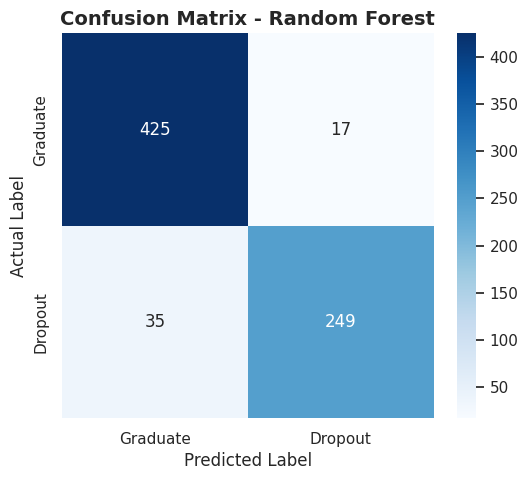

In [40]:
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Graduate (0)', 'Dropout (1)']))
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Graduate', 'Dropout'], 
            yticklabels=['Graduate', 'Dropout'])
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [42]:
os.makedirs('model', exist_ok=True)
joblib.dump(rf_model, 'model/rf_dropout_model.pkl')
joblib.dump(X.columns.tolist(), 'model/model_features.pkl')

print("Model and features saved successfully in 'model/' directory.")

Model and features saved successfully in 'model/' directory.
